<a href="https://colab.research.google.com/github/241b163-dot/algo/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greedy Knapsack Problem (Fractional)
In this lab, we explore the Fractional Knapsack Problem, a fundamental optimization problem that demonstrates the Greedy Algorithmic Paradigm.
We will implement it using greedy selection (based on value-to-weight ratio) and analyze its time and space complexity.

- Created by Dr. Ajay

# Problem Definition
Given a set of
n
n items, each with:
Value vi
Weight wi
A knapsack with maximum capacity **W**

Goal: maximize total value that can be put in the knapsack.
Constraint: You may take fractions of items.

Greedy Strategy:

*  Sort items by decreasing ratio vi/wi
*  Select items fully until knapsack is full.
*  Take fraction of the next item if capacity remains.

Maximum value in Knapsack: 240.0
Fractions taken (ID, Percentage): [(0, 1.0), (1, 1.0), (2, 0.6666666666666666)]


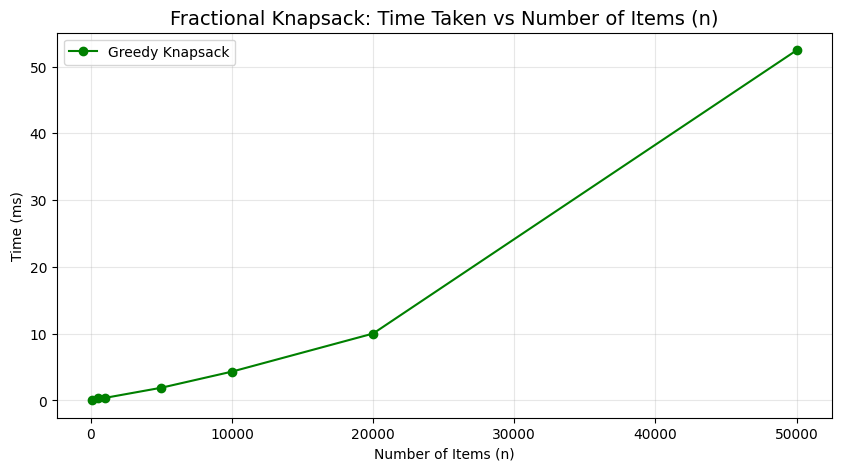

In [1]:
#write code for the above problem
import timeit
import matplotlib.pyplot as plt
import random

class Item:
    def __init__(self, value, weight, item_id):
        self.value = value
        self.weight = weight
        self.item_id = item_id
        # Greedy Strategy: Calculate the ratio vi/wi
        self.ratio = value / weight

def fractional_knapsack(items, capacity):
    # 1. Sort items by decreasing ratio vi/wi
    items.sort(key=lambda x: x.ratio, reverse=True)

    total_value = 0.0
    knapsack_contents = []

    for item in items:
        if capacity == 0:
            break

        if item.weight <= capacity:
            # 2. Select items fully if they fit
            capacity -= item.weight
            total_value += item.value
            knapsack_contents.append((item.item_id, 1.0)) # 1.0 means 100%
        else:
            # 3. Take fraction of the next item if capacity remains
            fraction = capacity / item.weight
            total_value += item.value * fraction
            knapsack_contents.append((item.item_id, fraction))
            capacity = 0 # Knapsack is now full

    return total_value, knapsack_contents

# --- Example Test Case ---
values = [60, 100, 120]
weights = [10, 20, 30]
W = 50

test_items = [Item(values[i], weights[i], i) for i in range(len(values))]
max_val, fractions = fractional_knapsack(test_items, W)

print(f"Maximum value in Knapsack: {max_val}")
print(f"Fractions taken (ID, Percentage): {fractions}")

# --- Performance Benchmarking ---

n_list = [100, 500, 1000, 5000, 10000, 20000, 50000]
greedy_times = []

for n in n_list:
    # Generate n random items
    bench_items = [Item(random.randint(10, 100), random.randint(1, 50), i) for i in range(n)]
    capacity = n * 5 # Scalable capacity

    start = timeit.default_timer()
    fractional_knapsack(bench_items, capacity)
    end = timeit.default_timer()

    greedy_times.append((end - start) * 1000)

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(n_list, greedy_times, marker='o', linestyle='-', color='green', label='Greedy Knapsack')
plt.title("Fractional Knapsack: Time Taken vs Number of Items (n)", fontsize=14)
plt.xlabel('Number of Items (n)')
plt.ylabel('Time (ms)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In this lab, we implement Huffman Coding, a greedy algorithm used for lossless data compression.
It assigns variable-length binary codes to input symbols based on their frequencies, ensuring that more frequent symbols receive shorter codes and less frequent symbols receive longer codes.

This algorithm constructs a binary tree (Huffman Tree) where each leaf node represents a character, and the path from the root to a leaf gives the character’s binary code.

Use:
Huffman Tree Construction using a Min-Priority Queue (Min-Heap).
Code generation for each character.
Encoding and decoding using the generated Huffman codes.
Complexity analysis and comparison with fixed-length encoding.

# Pseudocode:
1. Create a leaf node for each character and insert all nodes into a
2. min-heap by frequency.
   *  While the heap has more than one node:
   * Extract two nodes with the lowest frequencies.
   * Create a new internal node with frequency = sum of the two.
   *  Set the two extracted nodes as left and right children.
   *  Insert the new node back into the min-heap.
3. The remaining node is the root of the Huffman Tree.

4. Traverse the tree:
   * Assign 0 for left edge and 1 for right edge.
   * The resulting paths from root to leaves give Huffman codes.

<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:85: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_169/1544068143.py:85: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Huffman Coding: Time Complexity $O(n \log n)$")


Huffman Codes:
' ': 101
'h': 0000
'd': 0010
'e': 0100
'r': 0101
'o': 0110
'n': 1000
'f': 1001
'm': 1100
'g': 1101
'i': 1110
'a': 1111
'u': 00010
'y': 00011
'l': 00110
'c': 00111
's': 01110
't': 01111


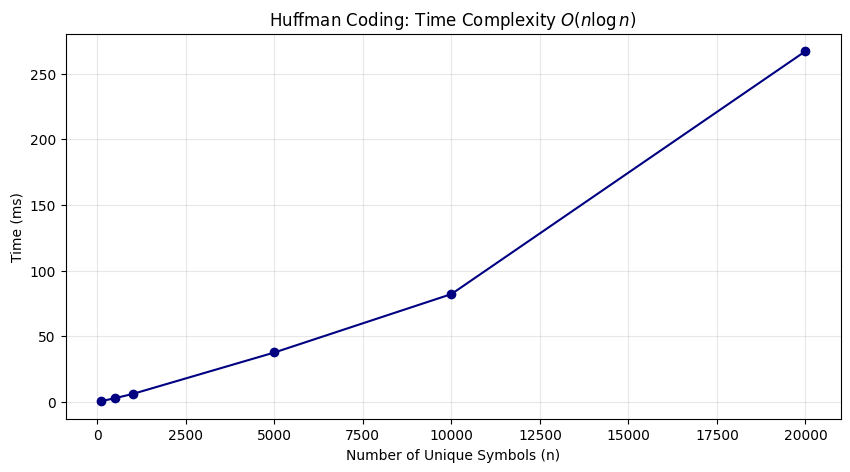

In [2]:
# write code for above
import heapq
import timeit
import matplotlib.pyplot as plt

class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    # Defining comparators for the priority queue (Min-Heap)
    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(frequencies):
    # 1. Create a leaf node for each character and insert into min-heap
    heap = [Node(char, freq) for char, freq in frequencies.items()]
    heapq.heapify(heap)

    # 2. While heap has more than one node
    while len(heap) > 1:
        # Extract two nodes with lowest frequencies
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        # Create new internal node with sum of frequencies
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right

        # Insert back into heap
        heapq.heappush(heap, merged)

    # 3. The remaining node is the root
    return heap[0]

def generate_codes(node, current_code="", codes={}):
    if node is None:
        return

    # If it's a leaf node (has a character)
    if node.char is not None:
        codes[node.char] = current_code

    # 4. Traverse: 0 for left, 1 for right
    generate_codes(node.left, current_code + "0", codes)
    generate_codes(node.right, current_code + "1", codes)
    return codes

# --- Example Usage ---
data = "huffman coding is a greedy algorithm"
# Calculate frequencies
freq_map = {}
for char in data:
    freq_map[char] = freq_map.get(char, 0) + 1

# Process
root = build_huffman_tree(freq_map)
huffman_codes = generate_codes(root)

print("Huffman Codes:")
for char, code in sorted(huffman_codes.items(), key=lambda x: len(x[1])):
    print(f"'{char}': {code}")

# --- Performance Analysis ---
n_list = [100, 500, 1000, 5000, 10000, 20000]
huffman_times = []

for n in n_list:
    # Generate dummy data with n unique characters/frequencies
    test_freqs = {f"char{i}": i for i in range(1, n + 1)}

    start = timeit.default_timer()
    tree = build_huffman_tree(test_freqs)
    generate_codes(tree, "", {})
    end = timeit.default_timer()

    huffman_times.append((end - start) * 1000)

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(n_list, huffman_times, marker='o', color='navy', label='Huffman Coding')
plt.title("Huffman Coding: Time Complexity $O(n \log n)$")
plt.xlabel("Number of Unique Symbols (n)")
plt.ylabel("Time (ms)")
plt.grid(True, alpha=0.3)
plt.show()
